# Exploratory Data Analysis

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


## Basic checks

In [2]:
df = pd.read_csv(root_dir + "/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"The shape of dataset: {df.shape} \n")

print(f"The number of NaN in the dataset: {df.isna().sum()} \n")

print(f"The columns or features present in the dataset are:\n {list(df.columns)}")

The shape of dataset: (7043, 21) 

The number of NaN in the dataset: customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64 

The columns or features present in the dataset are:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Analysis

In [4]:
# We exclude the customer ID from our analysis because it does not contribute to predicting churn 
# This only increases the data dimensionality unnecessarily.

df = df.drop(["customerID"], axis = 1)


In [5]:
def stack_plot(df, group, target, ax=None, figsize=(10,6)):
    """
    Generate a stacked bar plot between two variables.

    Parameters
    ----------
    df : pd.DataFrame
        Data containing the variables to plot.
    group : str
        Column name to group by on x-axis.
    target : str
        Column name to stack as values.
    ax : matplotlib.axes.Axes, optional
        Axes object to plot on. If None, a new figure and axes are created.
    figsize : tuple, optional
        Figure size if ax is None.
    """
    temp_df = (df.groupby([group, target]).size() / df.groupby(group)[target].count()) \
                .reset_index().pivot(columns=target, index=group, values=0)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    temp_df.plot(kind='bar', stacked=True, ax=ax, color=["green", "darkred"])
    ax.xaxis.set_tick_params(rotation=0)
    ax.set_xlabel(group)
    ax.set_ylabel('Churn Percentage')
    ax.grid()
    
    return ax

## Churn bases on Gender, Senior Citizen, Partner and Dependents

<Axes: xlabel='Dependents', ylabel='Churn Percentage'>

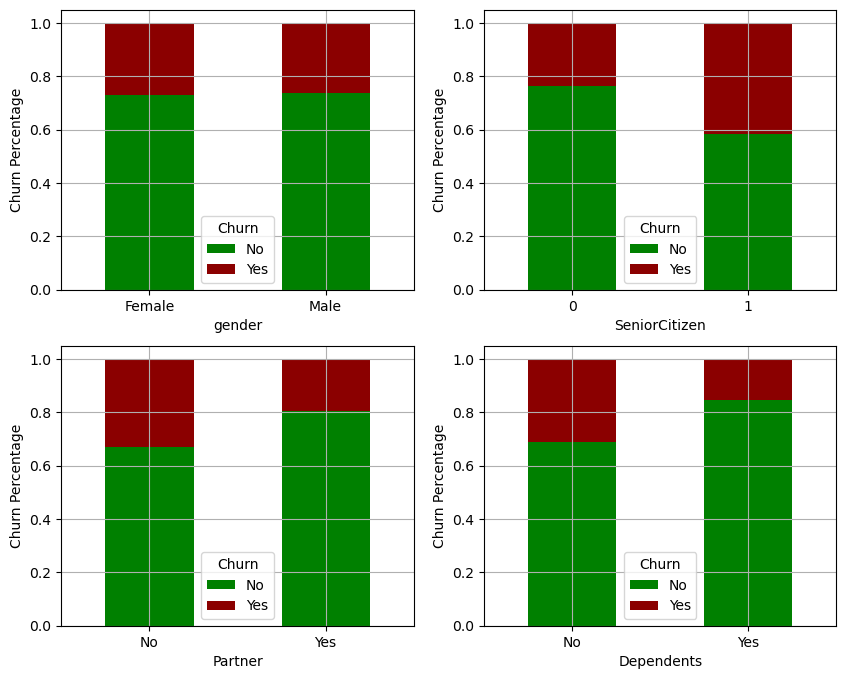

In [6]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

stack_plot(df, "gender", "Churn", ax = axes[0,0])
stack_plot(df, "SeniorCitizen", "Churn", ax = axes[0,1])
stack_plot(df, "Partner", "Churn", ax = axes[1,0])
stack_plot(df, "Dependents", "Churn", ax = axes[1,1])

From the plots above, we can observe the following:

- **Gender alone is not a strong predictor** of customer churn.  
- **Younger customers with families** tend to have lower churn rates. This may be influenced by factors such as a busy lifestyle, higher household income, or other related reasons.


In [7]:
# Person is young, with partner and dependents

subset = df[(df.SeniorCitizen == 0) & 
            (df.Partner == 'Yes') & 
            (df.Dependents == 'Yes')]["Churn"]

summary = pd.DataFrame({
    "Count": subset.value_counts(),
    "Percentage": subset.value_counts(normalize=True) * 100
})

summary

,Count,Percentage
Churn,,
No,1437,86.254502
Yes,229,13.745498


In [8]:
# Person is young, with partner and no dependents

subset = df[(df.SeniorCitizen == 0) & 
            (df.Partner == 'Yes') & 
            (df.Dependents == 'No')]["Churn"]

summary = pd.DataFrame({
    "Count": subset.value_counts(),
    "Percentage": subset.value_counts(normalize=True) * 100
})

summary

,Count,Percentage
Churn,,
No,921,79.191745
Yes,242,20.808255


In [9]:
# Person is young, with no partner and dependents

subset = df[(df.SeniorCitizen == 0) & 
            (df.Partner == 'No') & 
            (df.Dependents == 'Yes')]["Churn"]

summary = pd.DataFrame({
    "Count": subset.value_counts(),
    "Percentage": subset.value_counts(normalize=True) * 100
})

summary

,Count,Percentage
Churn,,
No,278,78.753541
Yes,75,21.246459


In [10]:
# Person is young, with no partner and no dependents

subset = df[(df.SeniorCitizen == 0) & 
            (df.Partner == 'Yes') & 
            (df.Dependents == 'Yes')]["Churn"]

summary = pd.DataFrame({
    "Count": subset.value_counts(),
    "Percentage": subset.value_counts(normalize=True) * 100
})

summary

,Count,Percentage
Churn,,
No,1437,86.254502
Yes,229,13.745498


## Tenure

In [11]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

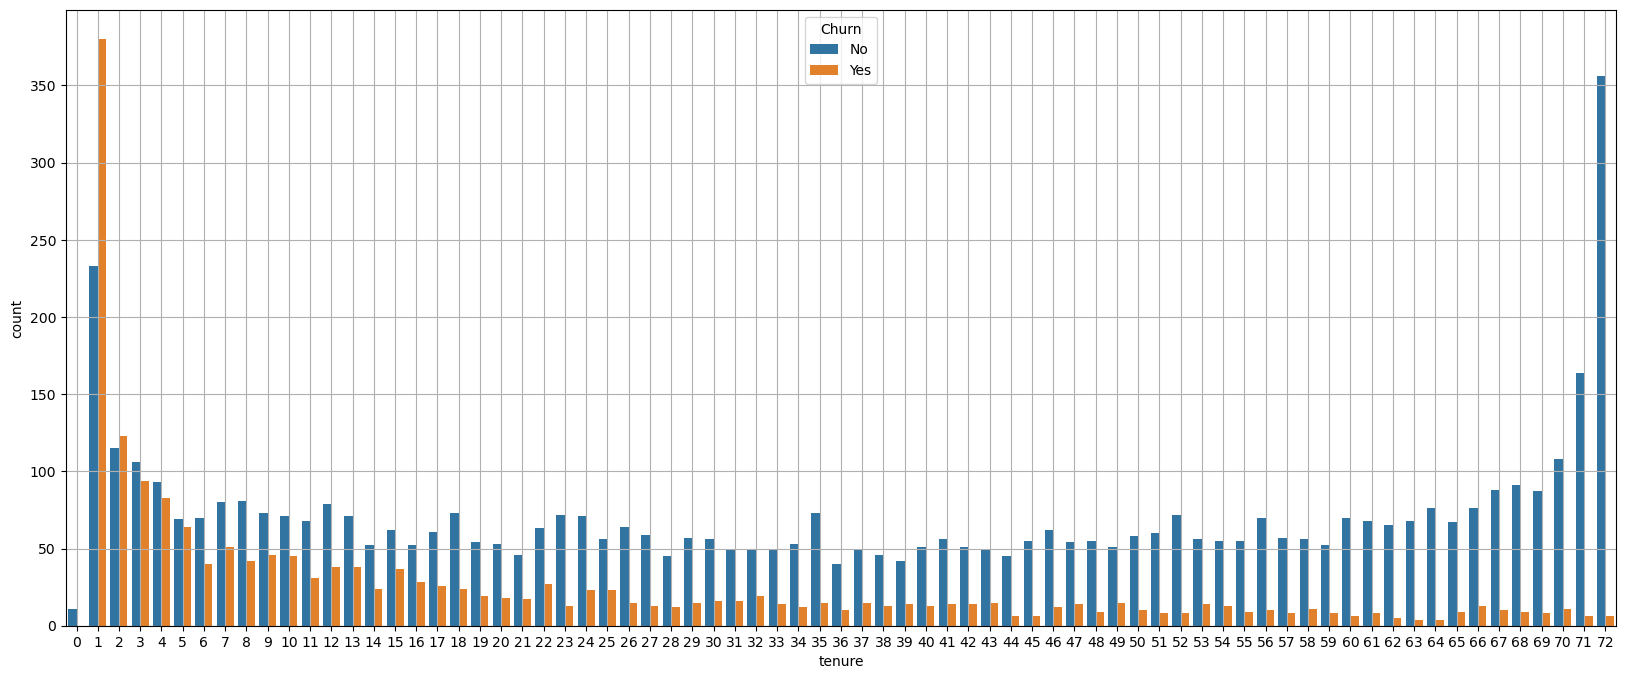

In [12]:
plt.figure(figsize=(20, 8))
sns.countplot(data=df, x="tenure", hue="Churn")
plt.grid()
plt.show()

- **Higher tenure correlates with lower churn rates**, indicating that customers tend to become more loyal over time.  
- For modeling purposes, tenure is **binned into 5 groups** to reduce complexity and improve interpretability.


In [13]:
def categorize_tenure(t):
    if t<=12:
        return 1
    elif t>12 and t<=24:
        return 2
    elif t>24 and t<=36:
        return 3
    elif t>36 and t<=48:
        return 4
    elif t>48 and t<=60:
        return 5
    else:
        return 6

df["tenure_group"]=df["tenure"].apply(lambda x: categorize_tenure(x))

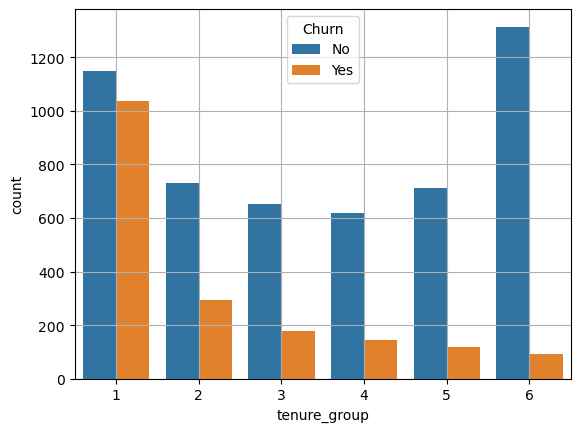

In [14]:
sns.countplot(data=df, x="tenure_group", hue="Churn")
plt.grid()

## Effect of Phone Services and Multiple Lines

<Axes: xlabel='InternetService', ylabel='Churn Percentage'>

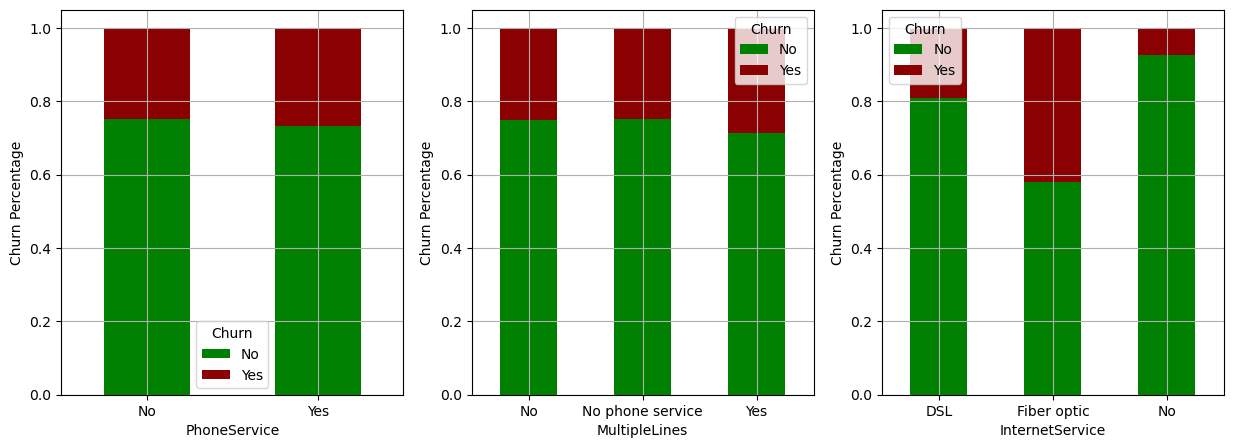

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

stack_plot(df, "PhoneService", "Churn", ax = axes[0])
stack_plot(df, "MultipleLines", "Churn", ax = axes[1])
stack_plot(df, "InternetService", "Churn", ax = axes[2])

From the plots, it's evident that Phone Services and Multiple Lines do not have added value in the model as it has similar churn rate.

When the internet service is **Fiber Optic**, the churn rate is noticeably higher compared to **DSL**.  
Although Fiber Optic offers faster speeds, the increased churn may be linked to its **higher cost**.  


## Effect of having Fiber optics on age (SeniorCitizen), partner and dependents

In [16]:
def normalized_countplot(data, x, hue, ax=None):
    # Compute normalized percentages
    temp = (
        data.groupby([x, hue])
        .size()
        .groupby(level=0)
        .apply(lambda s: s / s.sum())
    )
    temp.index =  temp.index.droplevel(1)
    temp = temp.reset_index()
    temp.columns = [x, hue, "Percentage"]
    # Plot as barplot (normalized)
    sns.barplot(data=temp, x=x, y="Percentage", hue=hue, ax=ax)
    ax.set_ylabel("Proportion")
    ax.set_ylim([0,1])

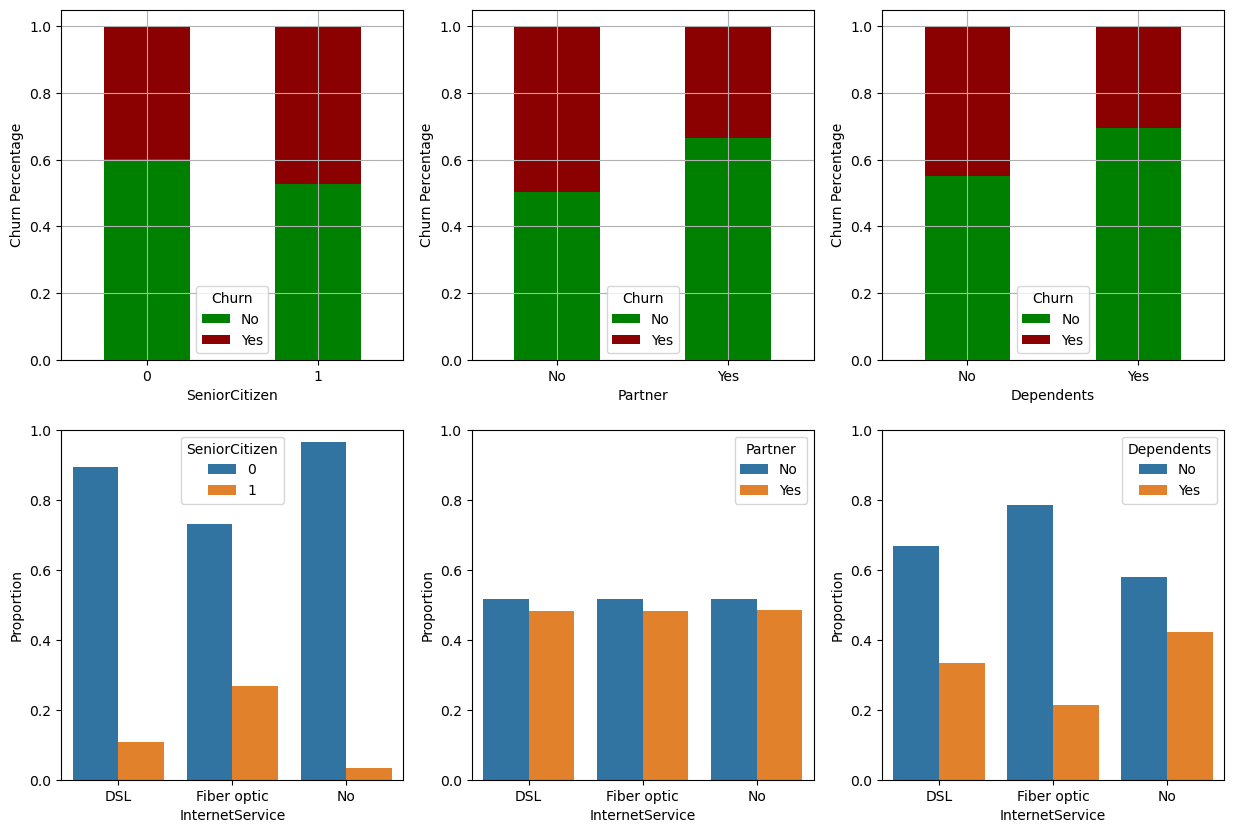

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

stack_plot(df[df["InternetService"]=="Fiber optic"], "SeniorCitizen", "Churn", ax = axes[0,0])
stack_plot(df[df["InternetService"]=="Fiber optic"], "Partner", "Churn", ax = axes[0, 1])
stack_plot(df[df["InternetService"]=="Fiber optic"], "Dependents", "Churn", ax = axes[0, 2])

normalized_countplot(data = df, x="InternetService", hue = "SeniorCitizen", ax = axes[1, 0])
normalized_countplot(data = df, x="InternetService", hue = "Partner", ax = axes[1, 1])
normalized_countplot(data = df, x="InternetService", hue = "Dependents", ax = axes[1, 2])



**Observations on Fiber Optic Churn**

- Customers using Fiber Optic as their Internet Service show a higher churn rate compared to DSL or no internet. The possible reason could be the higher cost of Fiber Optics.

- Partner and SeniorCitizen status do not explain this higher churn, suggesting that these demographic factors are not the main drivers.

- Customers without dependents are more likely to opt for Fiber Optic, and this group also exhibits a higher probability of churning.

**Conclusion**: The higher churn among Fiber Optic users is likely driven by cost sensitivity and household composition rather than age or partner status. Targeted retention strategies should focus on pricing plans and value-added services for single or dependent-free households.

## Effect of OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

<Axes: xlabel='StreamingMovies', ylabel='Churn Percentage'>

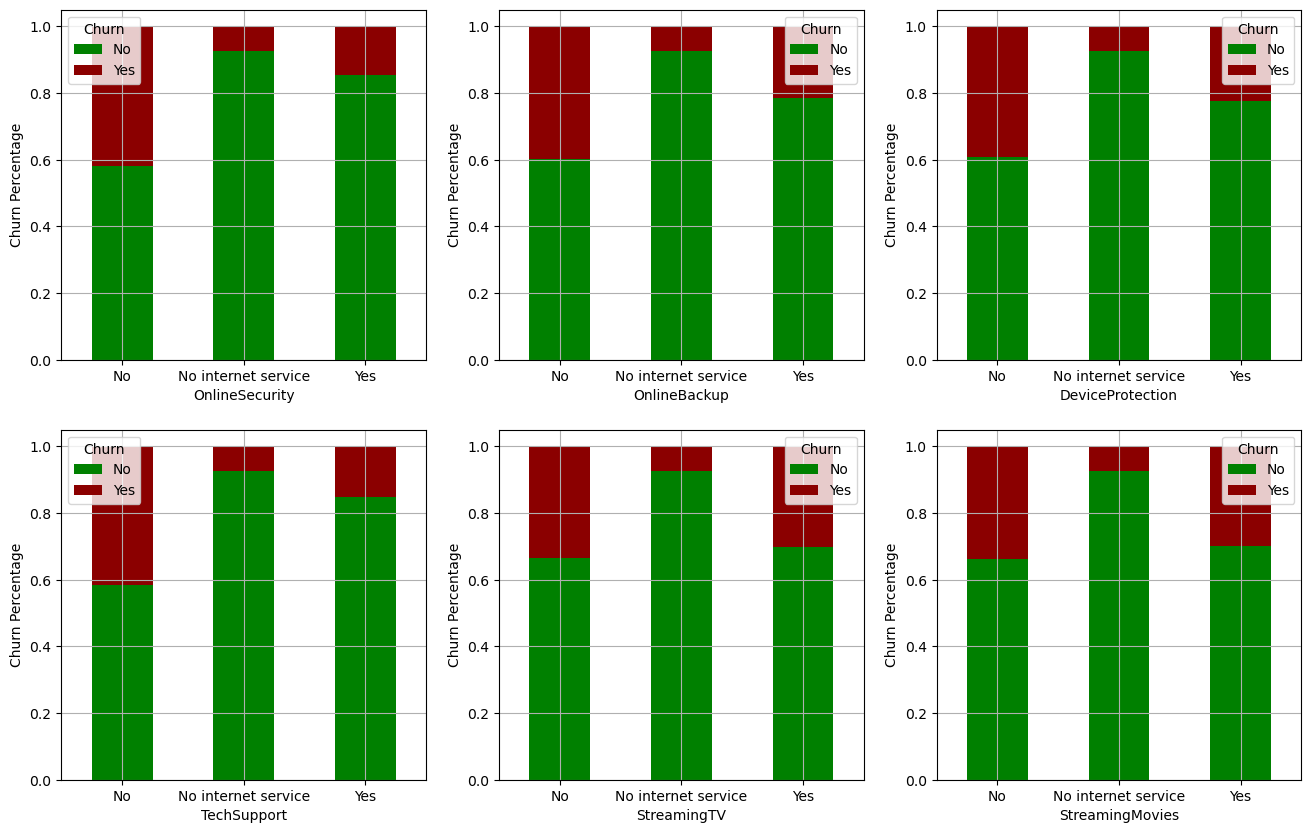

In [18]:
fig, axes = plt.subplots(2, 3, figsize= (16, 10))

stack_plot(df, "OnlineSecurity", "Churn", ax = axes[0,0])
stack_plot(df, "OnlineBackup", "Churn", ax = axes[0,1])
stack_plot(df, "DeviceProtection", "Churn", ax = axes[0,2])
stack_plot(df, "TechSupport", "Churn", ax = axes[1,0])
stack_plot(df, "StreamingTV", "Churn", ax = axes[1,1])
stack_plot(df, "StreamingMovies", "Churn", ax = axes[1,2])


- Across all categories, we observe consistent patterns:  
  - Customers **without internet service** have a **lower probability of churning**, possibly due to lower service costs.  
  - Among those with internet service, **not subscribing to specific add-on services** increases the likelihood of churn.


In [19]:
def plot_distribution_by_category(df, numeric_col, category_col, ax=None, title=None):
    """
    Plots the distribution of a numeric column grouped by a categorical column.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    numeric_col : str
        Name of the numeric column to plot (e.g., 'tenure').
    category_col : str
        Name of the categorical column (e.g., 'OnlineSecurity').
    ax : matplotlib.axes.Axes, optional
        Axes object to plot on. If None, a new figure and axes are created.
    title : str, optional
        Title of the plot.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    
    categories = df[category_col].unique()
    
    for cat in categories:
        sns.histplot(df[numeric_col][df[category_col] == cat], 
                     kde=True, 
                     stat="density", 
                     element="step", 
                     alpha=0.3, 
                     label=str(cat),
                     ax=ax)
    
    ax.set_xlabel(numeric_col)
    ax.set_ylabel("Density")
    ax.grid()
    ax.set_title(title if title else f"{numeric_col.capitalize()} Distribution by {category_col}")
    ax.legend()

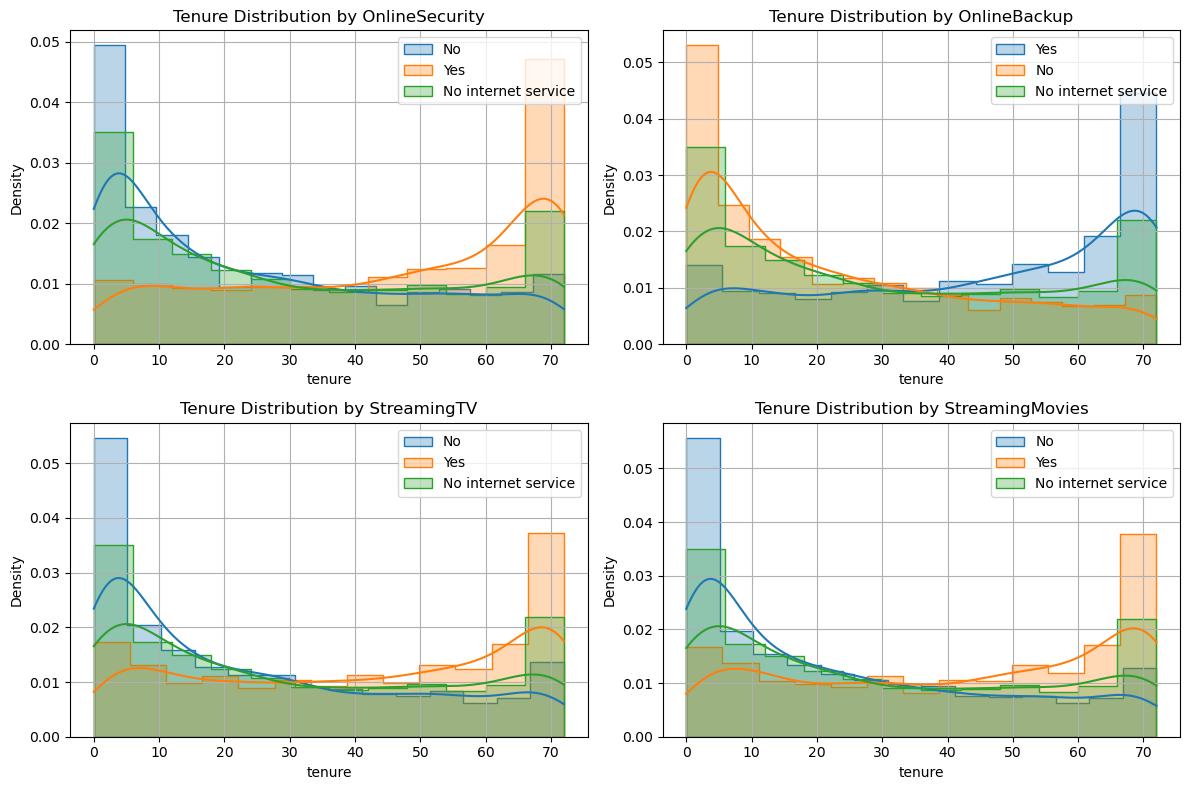

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(12,8))
plot_distribution_by_category(df, numeric_col="tenure", category_col="OnlineSecurity", ax=axes[0,0])
plot_distribution_by_category(df, numeric_col="tenure", category_col="OnlineBackup", ax=axes[0,1])
plot_distribution_by_category(df, numeric_col="tenure", category_col="StreamingTV", ax=axes[1,0])
plot_distribution_by_category(df, numeric_col="tenure", category_col="StreamingMovies", ax=axes[1,1])

plt.tight_layout()
plt.show()

## Effect of no InternetService on OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingMovies, StreamingTV

In [21]:
dependents = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingMovies", "StreamingTV"]

for dep in dependents:
    print(df[df["InternetService"]=="No"][dep].value_counts(), "\n")

OnlineSecurity
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No internet service    1526
Name: count, dtype: int64 

TechSupport
No internet service    1526
Name: count, dtype: int64 

StreamingMovies
No internet service    1526
Name: count, dtype: int64 

StreamingTV
No internet service    1526
Name: count, dtype: int64 



## Contract

<Axes: xlabel='InternetService', ylabel='count'>

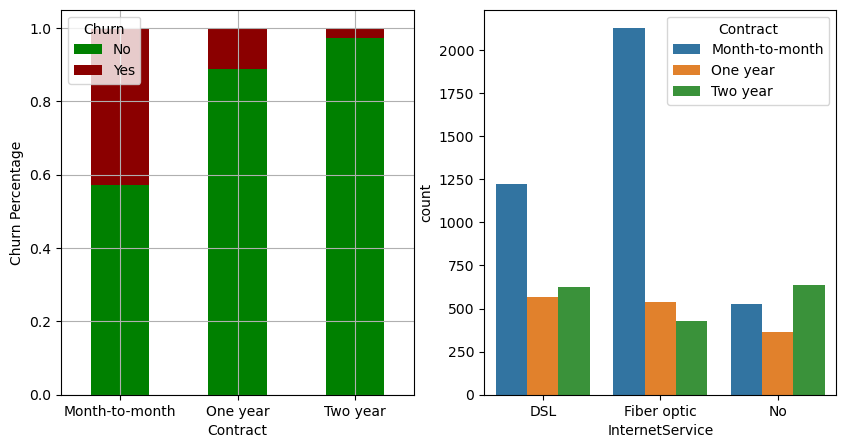

In [22]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

stack_plot(df,  "Contract", "Churn", ax = axes[0])
sns.countplot(df, x="InternetService", hue = "Contract")

- Customers on **Month-to-Month contracts** exhibit a significantly higher churn rate.  
- Some customers in the dataset may still be under **one-year or two-year contract plans**, which have lower churn.  
- Many Month-to-Month customers also choose **Fiber Optic** as their Internet service. This explains why the churn rate for Fiber Optic users is relatively high.


## Payment Methods

<Axes: xlabel='PaymentMethod', ylabel='count'>

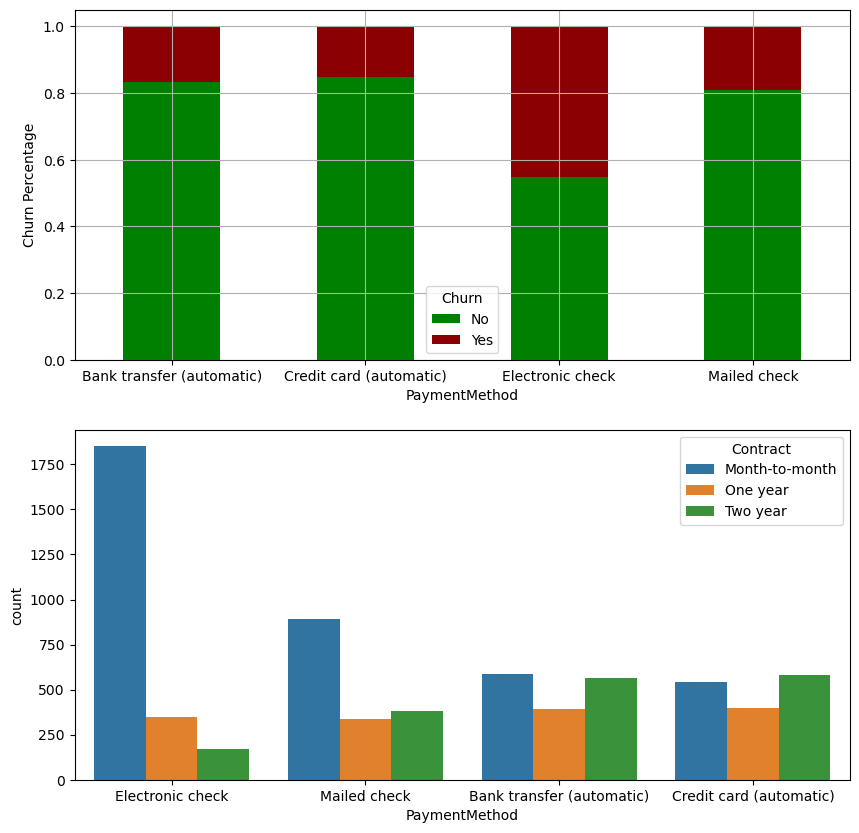

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

stack_plot(df, "PaymentMethod", "Churn", ax = ax[0])

sns.countplot(df, x="PaymentMethod", hue = "Contract", ax = ax[1])


- Customers on **Month-to-Month contracts** tend to pay mostly via **Electronic Check** or **Mailed Check**.  
- This preference may be due to the **easier cancellation process** compared to automatic payment methods, giving them more flexibility.


## Paperless Billing

<Axes: xlabel='PaperlessBilling', ylabel='Churn Percentage'>

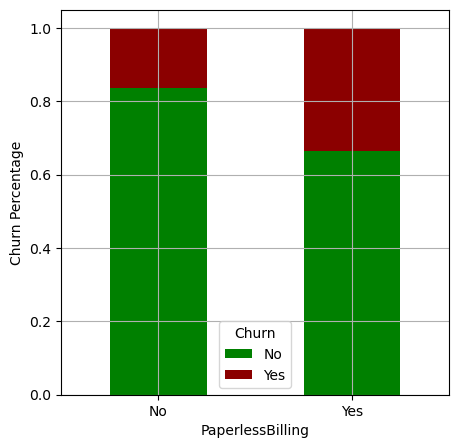

In [24]:
fig, ax = plt.subplots(figsize=(5,5))
stack_plot(df, "PaperlessBilling", "Churn", ax = ax)

## TotalCharges

In [25]:
df.TotalCharges.describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

In [26]:
df['TotalCharges'] = df["TotalCharges"].replace(" ",np.nan)
df['TotalCharges'].isna().sum() 


11

In [27]:
df[df["TotalCharges"].isnull()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,1
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,1
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,1
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,1
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,1
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,1
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,1
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,1
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,1
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,1


- Customers with **tenure = 0** have **null TotalCharges**, indicating they recently joined.  
- These missing values can be safely filled with **0**.


In [28]:
df.loc[df["TotalCharges"].isnull(), 'TotalCharges'] = 0
df.isnull().any().any()


False

In [29]:
df['TotalCharges'] = df["TotalCharges"].astype(float)

Churn = df[df.Churn=="Yes"]
Not_Churn = df[df.Churn=="No"]


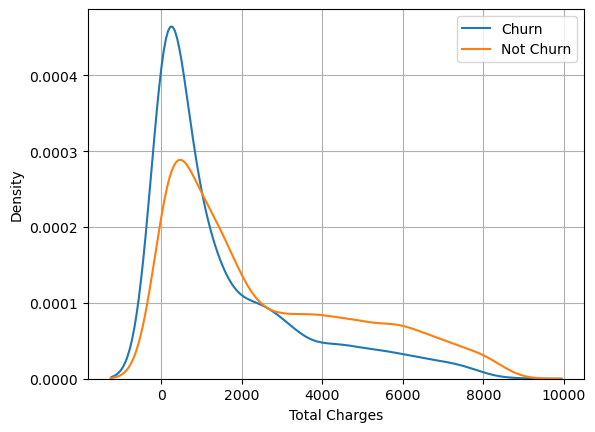

In [30]:
fig, ax = plt.subplots()
sns.kdeplot(Churn["TotalCharges"],label = "Churn", ax= ax)
sns.kdeplot(Not_Churn["TotalCharges"], label = "Not Churn", ax=ax)
ax.set_xlabel("Total Charges")
ax.grid()
ax.legend()

- The **density of TotalCharges** for **churning customers** is high near **0**.  
- This indicates that many customers **cancel their subscription within 1–2 months**.


## MonthlyCharges

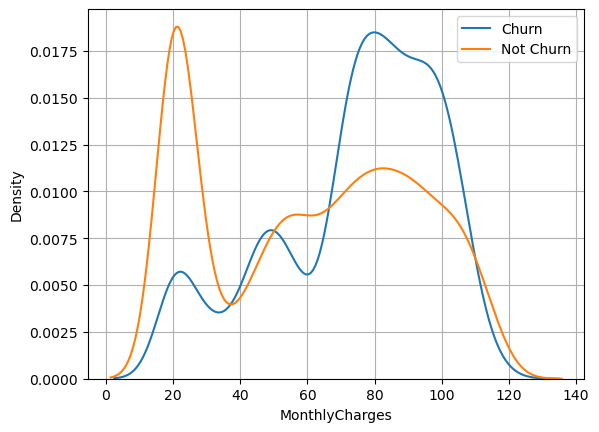

In [31]:
sns.kdeplot(Churn["MonthlyCharges"], label = "Churn")
sns.kdeplot(Not_Churn["MonthlyCharges"], label = "Not Churn")
plt.grid()
plt.legend()

The customers with high monthly charges churn more

In [32]:
# correlation of total charges and (monthly charges x tenure) to check if we have redundant information.

np.corrcoef(df.TotalCharges, df.tenure*df.MonthlyCharges)


array([[1.        , 0.99956055],
       [0.99956055, 1.        ]])

In [33]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,2
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,6
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1
